In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [2]:
spy = pd.read_csv('../data/SPY_features.csv', parse_dates=['date'], index_col='date').sort_index()
spy.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,-0.000535,-0.011262,171.691376,169.676133,...,0.000096,1,1,0,Winter,0,17.790001,0,0,-0.005744
2015-01-05,167.052658,201.720001,204.369995,201.350006,204.169998,169632600,-0.018059,-0.032239,170.977999,169.477819,...,0.003225,1,1,0,Winter,0,19.920000,0,0,0.004610
2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419,-0.042641,170.037469,169.213594,...,0.001344,1,1,0,Winter,0,21.120001,0,1,0.011310
2015-01-07,167.541260,202.309998,202.720001,200.880005,201.419998,125346700,0.012462,-0.025481,169.312267,169.034233,...,-0.005366,1,1,0,Winter,0,19.309999,0,1,-0.007167
2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,0.017745,0.001751,168.978638,169.050955,...,-0.009923,1,1,0,Winter,0,17.010000,0,0,-0.033414


In [3]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'is_earnings_week',
    'vix', 'is_major_event'
]
TARGET_CLS = 'target_direction'

spy_cls = spy[FEATURES + [TARGET_CLS]].dropna().copy()
print(spy_cls.shape)

(2515, 20)


In [4]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window + embargo,
                               start + train_window + embargo + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits

spy_folds = walk_forward_splits(spy_cls, train_window=189)
print("SPY folds:", len(spy_folds))

SPY folds: 55


In [5]:
# scale_pos_weight = count(DOWN) / count(UP) to handle class imbalance
neg = (spy_cls[TARGET_CLS] == 0).sum()
pos = (spy_cls[TARGET_CLS] == 1).sum()
scale_pos_weight = neg / pos
print(f'DOWN: {neg}, UP: {pos}, scale_pos_weight: {scale_pos_weight:.3f}')

DOWN: 1142, UP: 1373, scale_pos_weight: 0.832


In [6]:
fold_scores = []
spy_actual, spy_pred = [], []
feat_imp_list = []

for train_idx, test_idx in spy_folds:
    X_train = spy_cls.iloc[train_idx][FEATURES]
    y_train = spy_cls.iloc[train_idx][TARGET_CLS]
    X_test  = spy_cls.iloc[test_idx][FEATURES]
    y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_p = xgb.predict(X_test)

    feat_imp_list.append(xgb.feature_importances_)

    cm = confusion_matrix(y_test, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fold_scores.append({
        'accuracy':    accuracy_score(y_test, y_p),
        'f1':          f1_score(y_test, y_p, zero_division=0),
        'precision':   precision_score(y_test, y_p, zero_division=0),
        'recall':      recall_score(y_test, y_p, zero_division=0),
        'specificity': spec
    })
    spy_actual.extend(y_test)
    spy_pred.extend(y_p)

results_df = pd.DataFrame(fold_scores)
print(classification_report(spy_actual, spy_pred, zero_division=0))
print(results_df.describe())

              precision    recall  f1-score   support

           0       0.45      0.47      0.46      1038
           1       0.55      0.53      0.54      1272

    accuracy                           0.50      2310
   macro avg       0.50      0.50      0.50      2310
weighted avg       0.50      0.50      0.50      2310

        accuracy         f1  precision     recall  specificity
count  55.000000  55.000000  55.000000  55.000000    55.000000
mean    0.499567   0.517811   0.547004   0.524624     0.467054
std     0.079165   0.124967   0.103164   0.186157     0.179778
min     0.357143   0.250000   0.280000   0.190476     0.150000
25%     0.452381   0.427052   0.464461   0.374126     0.325758
50%     0.500000   0.512821   0.558824   0.550000     0.450000
75%     0.547619   0.598465   0.625000   0.645768     0.578947
max     0.690476   0.761905   0.750000   0.923077     0.869565


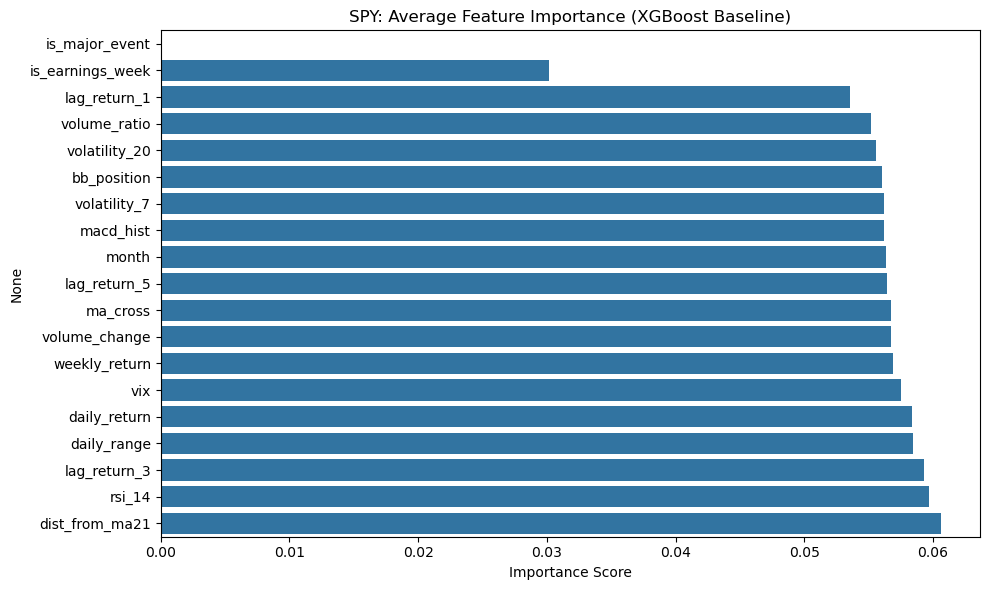

In [7]:
feat_imp = pd.DataFrame(feat_imp_list, columns=FEATURES).mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('SPY: Average Feature Importance (XGBoost Baseline)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [8]:
print(feat_imp.to_string())

is_major_event      0.000000
is_earnings_week    0.030167
lag_return_1        0.053525
volume_ratio        0.055211
volatility_20       0.055574
bb_position         0.056031
volatility_7        0.056180
macd_hist           0.056223
month               0.056346
lag_return_5        0.056453
ma_cross            0.056709
volume_change       0.056733
weekly_return       0.056925
vix                 0.057547
daily_return        0.058380
daily_range         0.058422
lag_return_3        0.059282
rsi_14              0.059670
dist_from_ma21      0.060623


In [9]:
from itertools import product

n_estimators_values = [100, 200, 500]
max_depth_values    = [3, 4, 6]
learning_rate_values = [0.01, 0.05, 0.1]
subsample_values    = [0.7, 0.8, 1.0]

combos = list(product(n_estimators_values, max_depth_values, learning_rate_values, subsample_values))
print(f'Grid: {len(n_estimators_values)} n_est x {len(max_depth_values)} depth x {len(learning_rate_values)} lr x {len(subsample_values)} subsample = {len(combos)} combinations')
print(f'Folds per combo: {len(spy_folds)}')
print(f'Total XGB fits: {len(combos) * len(spy_folds)}')

Grid: 3 n_est x 3 depth x 3 lr x 3 subsample = 81 combinations
Folds per combo: 55
Total XGB fits: 4455


In [10]:
grid_results = []

for n_est, max_d, lr, subs in combos:
    fold_f1s, fold_accs, fold_precs, fold_recs, fold_specs = [], [], [], [], []

    for train_idx, test_idx in spy_folds:
        X_train = spy_cls.iloc[train_idx][FEATURES]
        y_train = spy_cls.iloc[train_idx][TARGET_CLS]
        X_test  = spy_cls.iloc[test_idx][FEATURES]
        y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

        xgb = XGBClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subs,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        xgb.fit(X_train, y_train)
        y_p = xgb.predict(X_test)

        fold_f1s.append(f1_score(y_test, y_p, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_p))
        fold_precs.append(precision_score(y_test, y_p, zero_division=0))
        fold_recs.append(recall_score(y_test, y_p, zero_division=0))

        cm = confusion_matrix(y_test, y_p, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    grid_results.append({
        'n_estimators':  n_est,
        'max_depth':     max_d,
        'learning_rate': lr,
        'subsample':     subs,
        'f1':          np.mean(fold_f1s),
        'accuracy':    np.mean(fold_accs),
        'precision':   np.mean(fold_precs),
        'recall':      np.mean(fold_recs),
        'specificity': np.mean(fold_specs),
    })
    print(f'  n_est={n_est:>3}  depth={max_d}  lr={lr:.2f}  subs={subs:.1f}  '
          f'F1={np.mean(fold_f1s):.3f}  acc={np.mean(fold_accs):.3f}  '
          f'prec={np.mean(fold_precs):.3f}  rec={np.mean(fold_recs):.3f}  spec={np.mean(fold_specs):.3f}')

xgb_grid_df = pd.DataFrame(grid_results)

  n_est=100  depth=3  lr=0.01  subs=0.7  F1=0.496  acc=0.512  prec=0.548  rec=0.521  spec=0.492
  n_est=100  depth=3  lr=0.01  subs=0.8  F1=0.494  acc=0.513  prec=0.546  rec=0.521  spec=0.494
  n_est=100  depth=3  lr=0.01  subs=1.0  F1=0.489  acc=0.512  prec=0.558  rec=0.502  spec=0.506
  n_est=100  depth=3  lr=0.05  subs=0.7  F1=0.514  acc=0.502  prec=0.552  rec=0.523  spec=0.472
  n_est=100  depth=3  lr=0.05  subs=0.8  F1=0.528  acc=0.513  prec=0.564  rec=0.537  spec=0.478
  n_est=100  depth=3  lr=0.05  subs=1.0  F1=0.505  acc=0.504  prec=0.557  rec=0.507  spec=0.496
  n_est=100  depth=3  lr=0.10  subs=0.7  F1=0.520  acc=0.498  prec=0.547  rec=0.528  spec=0.460
  n_est=100  depth=3  lr=0.10  subs=0.8  F1=0.522  acc=0.508  prec=0.556  rec=0.533  spec=0.476
  n_est=100  depth=3  lr=0.10  subs=1.0  F1=0.532  acc=0.513  prec=0.559  rec=0.543  spec=0.477
  n_est=100  depth=4  lr=0.01  subs=0.7  F1=0.509  acc=0.513  prec=0.555  rec=0.534  spec=0.479
  n_est=100  depth=4  lr=0.01  subs=0.8 

In [11]:
print('Top 5 by F1:')
print(xgb_grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('\nTop 5 by Accuracy:')
print(xgb_grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('\nTop 5 by Precision:')
print(xgb_grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('\nTop 5 by Specificity:')
print(xgb_grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nBaseline (n_est=100, depth=4, lr=0.1, subs=0.8):')
baseline = xgb_grid_df[
    (xgb_grid_df['n_estimators'] == 100) &
    (xgb_grid_df['max_depth'] == 4) &
    (xgb_grid_df['learning_rate'] == 0.1) &
    (xgb_grid_df['subsample'] == 0.8)
]
print(baseline.to_string(index=False))

Top 5 by F1:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          500          6           0.10        1.0 0.545008  0.516883   0.568013 0.560771     0.467141
          500          3           0.10        0.8 0.542878  0.516017   0.565484 0.558555     0.467383
          500          3           0.05        0.8 0.541758  0.516450   0.566080 0.553167     0.473624
          500          4           0.10        0.7 0.541521  0.513420   0.560827 0.557490     0.467650
          200          6           0.10        1.0 0.540650  0.512987   0.559318 0.556617     0.464683

Top 5 by Accuracy:
 n_estimators  max_depth  learning_rate  subsample       f1  accuracy  precision   recall  specificity
          500          6           0.10        1.0 0.545008  0.516883   0.568013 0.560771     0.467141
          500          4           0.01        0.8 0.534823  0.516883   0.569753 0.543677     0.480084
          500          3           0.05 